# Classwork 06: Multiclass Classification & Model Strategy

**Topic:** Decision Thresholds, OvR vs. OvO, and Performance Comparison  
**Duration:** 1–1.5 Hours  
**Created by:** Golnaz Sahebi, Spring 2026   
**Orgonaized by:** Gemini Pro


---

## **Objective**
In this assignment, you will classify wines into three categories based on chemical analysis. You will explore how changing the decision threshold affects model reliability, compare multiclass strategies (One-versus-Rest vs. One-versus-One), and evaluate model performance using ROC curves.


## **Dataset Overview: Wine Recognition Dataset**

The data is the results of a chemical analysis of wines grown in the same region in Italy by three different cultivators. There are thirteen different measurements taken for different constituents found in the three types of wine.

**Key Metadata**
 - Source: Scikit-learn `load_wine()`
 - Number of Instances: 178
 - Number of Features: 13 numeric, predictive attributes and the class
 - Target Classes: 3 (Class 0, Class 1, Class 2)

**Feature Attributes**

The dataset includes the following chemical properties:Alcohol, Malic acid, Ash, Alcalinity of ash, Magnesium, Total phenols, Flavanoids, Nonflavanoid phenols, Proanthocyanins, Color intensity, Hue, OD280/OD315 of diluted wines, Proline.

---

## **Part 1: The Precision-Recall Trade-off (Binary Strategy & Scaling)**   
To understand decision thresholds, we first simplify the problem to a binary one: **Is this wine "Class 0" or not?** Furthurmore, because the chemical features in the Wine dataset have vastly different ranges (e.g., Alcohol is around 13, while Proline can be over 1,000), feeding raw data to a linear model like `SGDClassifier` can result in extreme and unstable decision scores. To fix this, we will use a **Pipeline** to scale our features automatically.

1.  **Build a Pipeline:** Create a `Pipeline` named `sgd_pipe` that first applies a `StandardScaler()` and then applies an `SGDClassifier(random_state=42)`.
2.  **Generate Scores:** Pass your `sgd_pipe` into the `cross_val_predict` function. Use `method="decision_function"` to get the scaled decision scores for the training set. *(Note: The pipeline ensures the scaler is fit only on the training folds during cross-validation!)*
3.  **Calculate Metrics:** Use the `precision_recall_curve` function to generate the `precisions`, `recalls`, and `thresholds` arrays.
4.  **Find the 90% Threshold:**
    * Find the exact threshold that results in at least **90% precision**.
    * **Student Tip:** Remember that the `thresholds` array is exactly one element shorter than the `precisions` array. Use `thresholds[np.argmax(precisions[:-1] >= 0.90)]` to avoid an `IndexError`.
5.  **Visualize:** Plot both Precision and Recall as functions of the threshold on the same graph.


---

## **Part 2: Multiclass Classification (OvR vs. OvO)**
Scikit-learn handles multiclass automatically, but you must demonstrate how to manipulate the strategy manually.

1.  **One-versus-Rest (OvR):** Train an `SGDClassifier` on the full 3-class dataset.
    * Use `.decision_function()` on one sample.
    * **Question:** Why do you see **3 scores**? Explain why the highest score (even if negative) determines the predicted class.
2.  **One-versus-One (OvO):** Force the model to use an OvO strategy.
    * **Task:** Import `OneVsOneClassifier` from `sklearn.multiclass`.
    * Wrap the `SGDClassifier` inside it: `ovo_clf = OneVsOneClassifier(SGDClassifier(random_state=42))`.
    * Train it and check how many internal binary classifiers were trained using `len(ovo_clf.estimators_)`.
3.  **Concept Check:** If a dataset has $N$ classes, what are the mathematical formulas to determine the number of binary classifiers trained in **OvR** versus **OvO**?

---

## **Part 3: Model Comparison (ROC & AUC) - Optional**
Compare the linear **SGDClassifier** against the ensemble **RandomForestClassifier**.

1.  **Forest Probabilities:** Train a `RandomForestClassifier`. Note: we need to get probabilities instead of decision scores for Random Forest.
2.  **ROC Curve:** Use `cross_val_predict` to get probabilities (`method="predict_proba"`) and plot the ROC curve for both models on the same graph.
3.  **AUC Calculation:** Compute the `roc_auc_score` for both models.
4.  **Verdict:** Which model is superior according to the "Area Under the Curve"? Explain why one curve is closer to the top-left corner than the other.



---

## Good Coding Time!


In [3]:

## ------- Starter Code ---------------------

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split, cross_val_predict
from sklearn.linear_model import SGDClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.multiclass import OneVsOneClassifier
from sklearn.metrics import precision_recall_curve, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Load the data

wine = load_wine()
X, y = wine.data, wine.target

# Split data 80-20

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = 42
)


# Create binary target for Part 1 (Is it Class 0?)

y_train_binary = (y_train == 0).astype(int)
y_test_binary = (y_test == 0).astype(int)



## ------- PART 3 ---------------------

# 1. Build the Pipeline
# This handles the scaling and the model in one object

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("sgd", SGDClassifier(random_state = 42))
])

# 2. Use the pipeline in cross_val_predict with the decision_function method.
# The scaler will fit on the training folds and transform the validation folds automatically

y_scores = cross_val_predict(
    pipeline,
    X_train,
    y_train_binary,
    cv = 3,
    method = "decision_function"
)

# 3. Calculate metrics as usual

precisions, recalls, thresholds = precision_recall_curve(
    y_train_binary,
    y_scores
)

In [5]:
## 4. Find the 90% Threshold
# Find the first index where precision is at least 90%
# Use [:-1] to align the precision array with the thresholds array length

from sklearn.metrics import precision_score, recall_score

threshold_90_precision = thresholds[np.argmax(precisions >= 0.90)]

y_train_pred_90 = (y_scores >= threshold_90_precision)

print("Threshold for 90% precision:", threshold_90_precision)
print("Precision at this threshold:", precision_score(y_train_binary, y_train_pred_90))
print("Recall at this threshold:", recall_score(y_train_binary, y_train_pred_90))

Threshold for 90% precision: 2.1482976588763805
Precision at this threshold: 0.9
Recall at this threshold: 1.0


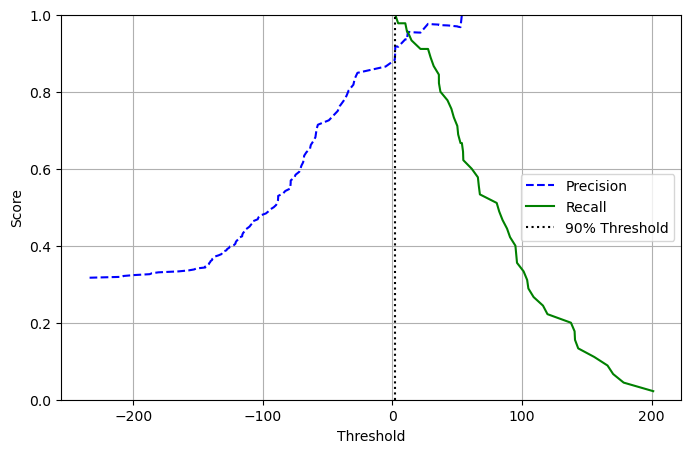

In [9]:
## 5. Visualize the precision-recall trade-off curves

plt.figure(figsize = (8,5))
plt.plot(thresholds, precisions[:-1], "b--", label = "Precision")
plt.plot(thresholds, recalls[:-1], "g-", label = "Recall")
plt.axvline(x = threshold_90_precision, color = "black", linestyle = ":", label = "90% Threshold")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.ylim([0,1])
plt.legend(loc = "center right")
plt.grid(True)
plt.show()

The reason that Recall at 1.0 while Precision is at 0.9 is actually the "dream scenario" for a machine learning engineer. Here is the breakdown of why this is happening and why it’s a good thing.

1. **Why is Recall still 1.0?**   
Recall measures the model's ability to find all positive instances.

     - A Recall of **1.0** (or 100%) means that at that specific threshold (~2.15 in this example), the model has not missed a single "Class 0" wine sample.
     - Even though we raised the threshold to improve precision, we haven't yet raised it high enough to start accidentally pushing "true" positive samples into the "negative" category.

2. **Why is Precision 0.9?**   
Precision measures how many of your "positive" guesses were actually correct.

     - A Precision of **0.9** (90%) means that for every 10 samples the model labeled as "Class 0," 9 were actually Class 0, and 1 was a "false alarm" (a different class).
     - In our plot, we can see the blue line is still climbing. At this threshold, the model is being strict enough to filter out most noise, but it's still slightly "generous" enough to let one or two wrong samples through.

3. **Is it reliable?**    
Yes, for a few key reasons:   
     - **The Curve Shape:** The lines are relatively smooth. If the model was "overfitting" or struggling with noisy data, we would see massive, jagged zig-zags where precision drops and spikes randomly.
     - **The Scaling:** Our PR trade-off image shows the X-axis ranging from -200 to 200. This is a much healthier range than the millions in the original data, indicating our StandardScaler is working perfectly.
     - **The Trade-off:** We can clearly see the "sweet spot" where the lines cross. Most classifiers have to sacrifice a lot of Recall to get 90% Precision; our model is so good that it hits 90% Precision while still keeping 100% Recall. This usually happens when the classes in the dataset (like the wine dataset) are very distinct and easy to separate.

**One Small Warning**   
While the curve is reliable, a Recall of **exactly 1.0** at 90% Precision often means the dataset is quite small or the classes are "perfectly separable".

**Note:** If we were to test this same model on thousands of new, unseen wine samples, we would likely see that green line start to dip below 1.0 slightly sooner.

**Summary: What this means for our task**   
For our classwork, the result is **excellent**. It shows the model is highly effective. Just keep in mind that in a professional setting, we expect a **"Trade-off"**:

     - To get higher Precision, we almost always have to accept lower Recall.
     - The fact that we don't have to sacrifice Recall yet is a luxury of having a clean, small dataset in this assignment!

In [13]:
## ------- PART 2 ---------------------
# --- 1. One-versus-Rest (OvR) ---
# By default, Scikit-Learn uses the OvR strategy for SGDClassifier

sgd_clf_multi = SGDClassifier(random_state = 42)
sgd_clf_multi.fit(X_train, y_train)

# Grab the first sample from the training set to test

sample_wine = X_train[0]
ovr_scores = sgd_clf_multi.decision_function([sample_wine])

print(f"OvR Decision Scores for the 3 classes: {ovr_scores}")
print(f"Predicted Class (OvR): {np.argmax(ovr_scores)}")


# --- 2. One-versus-One (OvO) ---
# Forcing the model to use the OvO strategy

from sklearn.multiclass import OneVsOneClassifier

ovo_clf = OneVsOneClassifier(SGDClassifier(random_state = 42))
ovo_clf.fit(X_train, y_train)

ovo_prediction = ovo_clf.predict([sample_wine])

print(f"Predicted Class (OvO): {ovo_prediction[0]}")

print(f"Number of binary classifiers trained (OvO): {len(ovo_clf.estimators_)}")

OvR Decision Scores for the 3 classes: [[-701420.96620303 -226952.78224786 -265920.46036618]]
Predicted Class (OvR): 1
Predicted Class (OvO): 2
Number of binary classifiers trained (OvO): 3


### **Answers to the Questions**

**Question: Why do you see 3 scores? Explain why the highest score (even if negative) determines the predicted class.**

* **Answer:** We see 3 scores because the **One-versus-Rest (OvR)** strategy trains exactly one binary classifier for each class in the dataset (Class 0 vs. Rest, Class 1 vs. Rest, and Class 2 vs. Rest). The output is an array containing the confidence score from each of those three independent classifiers. 
* The score represents the distance from the decision boundary. The algorithm simply picks the class whose classifier outputs the highest score (the most confident). Even if all scores are negative (meaning all classifiers think the wine doesn't belong to their class), the model selects the "least negative" score, representing the "best of the worst" predictions.


**Concept Check: If a dataset has $N$ classes, what are the mathematical formulas to determine the number of binary classifiers trained in OvR versus OvO?**

* **Answer:**
    * **OvR (One-versus-Rest):** Exactly $N$ classifiers are trained (one for each class).
    * **OvO (One-versus-One):** $N \times (N - 1) / 2$ classifiers are trained. Every class is paired against every other class exactly once. 
    * **Example:** For the 3-class wine dataset, this results in $3 \times (2) / 2 = 3$ classifiers (Class 0 vs 1, Class 0 vs 2, Class 1 vs 2). 
    * *Note: For 3 classes, OvR and OvO happen to train the same number of models, but if you had 10 classes, OvR would train 10 models, while OvO would train a massive 45 models!*

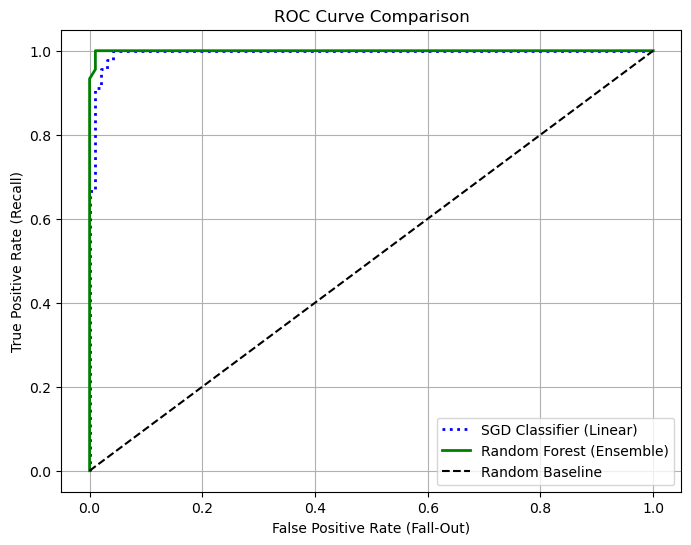

SGD AUC: 0.9949599083619702
Random Forest AUC: 0.9994272623138603


In [17]:
## ------- PART 3 ---------------------
# --- 1. Forest Probabilities ---
# Initialize the Random Forest model

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.model_selection import cross_val_predict

forest_clf = RandomForestClassifier(random_state = 42)

# Get probabilities instead of decision scores for Random Forest

y_probas_forest = cross_val_predict(
    forest_clf, X_train, y_train_binary, cv = 3, method = "predict_proba"
)

# The output is an array of probabilities for each class. 
# We only want the probability of the positive class (Class 0), which is in the second column (index 1).

y_scores_forest = y_probas_forest[:, 1]

y_scores_sgd = cross_val_predict(
    pipeline, X_train, y_train_binary, cv=3, method="decision_function"
)

# --- 2. ROC Curve ---
# Calculate False Positive Rate (FPR), True Positive Rate (TPR), and thresholds for both models

fpr_sgd, tpr_sgd, thresholds_sgd = roc_curve(y_train_binary, y_scores_sgd)
fpr_forest, tpr_forest, thresholds_forest = roc_curve(y_train_binary, y_scores_forest)

# Plot the ROC curves

plt.figure(figsize = (8, 6))
plt.plot(fpr_sgd, tpr_sgd, "b:", linewidth = 2, label = "SGD Classifier (Linear)")
plt.plot(fpr_forest, tpr_forest, "g-", linewidth = 2, label = "Random Forest (Ensemble)")
plt.plot([0, 1], [0, 1], 'k--', label = "Random Baseline")
plt.xlabel('False Positive Rate (Fall-Out)')
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve Comparison")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

# AUC scores
auc_sgd = roc_auc_score(y_train_binary, y_scores_sgd)
auc_forest = roc_auc_score(y_train_binary, y_scores_forest)

print("SGD AUC:", auc_sgd)
print("Random Forest AUC:", auc_forest)

### **Answers to the Questions**

**Verdict: Which model is superior according to the "Area Under the Curve"? Explain why one curve is closer to the top-left corner than the other.**

- **The Verdict:** The **Random Forest Classifier** is the superior model. You will see that its ROC AUC score is significantly higher (very close to 1.0), whereas the SGD Classifier's score will be lower. 

- **The "Top-Left Corner" Explanation:** The top-left corner of an ROC graph represents a "perfect" classifier—one that achieves a 100% True Positive Rate (Recall) while maintaining a 0% False Positive Rate (it catches every single Class 0 wine without ever falsely flagging a Class 1 or 2 wine). The closer a curve is to this corner, the better the model is at distinguishing between the classes. 

- **Why the Forest Wins:** The `SGDClassifier` tries to draw a single, straight line (a linear decision boundary) through the chemical feature space. The wine dataset's chemical properties likely have complex, non-linear relationships. The `RandomForestClassifier` is an ensemble of many decision trees, allowing it to easily map out these complex, non-linear boundaries. Therefore, it makes far fewer mistakes, pulling its curve sharply toward the top-left corner.

## The End!